# Test the newly implemented functions in the AERA extended to aragonite saturation state

25.06.2025

## AERA for `temp`

### `core.py`

In [1]:
import copy as cp
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from scipy.optimize import curve_fit

from aera import constants
from aera import utils
from aera import io
from aera import emission_curve

/home/leyvraz/projects/aera/aera/utils.py:50: SyntaxWarning: invalid escape sequence '\s'
  f, header=None, index_col=0, sep="\s+") # Modified from original AERA version to avoid FutureWarning


In [2]:
# Not needed for aragonite => no need to test
def runmean(array, winlen):
    """Calculates a running mean of any timeseries using a window
    length (winlen).

    Args:
        array: timeseries over which the running mean is calculated
        winlen: window length of running mean
    """
    return np.convolve(array, np.ones((winlen)) / winlen, mode='same')

In [3]:
# Not needed for aragonite => no need to test
def extrapolated_runmean(array, winlen):
    """Extrapolates a running mean at the beginning and end of the 
    time series. At the beginning, the window size is simply reduced. 
    At the end, which is critical for the t_anth estimation at the 
    stocktake, the running mean is linearly extrapolated. This is 
    done by calculating the slope over the last 31 (generally winlen) 
    years and adding a linear spline with this slope to the last 
    valid running mean value 17 (generally int(winlen / 2) +1) years 
    before stocktake to obtain the estimates for the last 15 
    (generally int(winlen / 2)) years before stocktake.

    Args:
        array: timeseries over which the running mean is calculated
        winlen: window length of running mean
    """
    array_runmean = runmean(array, winlen)

    # Reduce window size down to int(winlen / 2) + 1
    # for the first int(winlen / 2) elements.
    array_runmean[:int(winlen / 2)] = np.array([
        np.mean(array[:int(winlen / 2) + i + 1])
        for i in range(int(winlen / 2))
    ])

    # Replace the last int(winlen / 2) elements by a linear extrapolation.
    array_runmean[-int(winlen / 2):] =\
        array_runmean[-int(winlen / 2) - 1]\
        + np.polyfit(np.arange(winlen), array[-winlen:], deg=1)[0]\
        * np.arange(1, int(winlen / 2) + 1)

    return array_runmean

In [4]:
# Not needed for aragonite => no need to test
def extrapolated_runmean_anth_temp(year_x, model_start_year, s_temp, winlen):
    """Calculate an extrapolated running mean of the simulated temperature.

    Args:
        year_x: Year of the sticktake
        model_start_year (int): Year in which the historical
            simulation (pre-cursor for the adaptive scenario
            simulation) was started.
        s_temp: Simulated termperature timeseries
        winlen: window length of running mean for temperature fit

    Returns:
        Extrapolated running mean of the simulated temperature 

    """
    temp = np.array(s_temp.loc[model_start_year:year_x])

    return extrapolated_runmean(temp, winlen)

In [5]:
# Not needed for aragonite => no need to test
def calculate_absolute_target_temperature(
        temp_target_rel, model_start_year, s_temp, winlen,
        temp_target_type, costum_anth_temp_func=None):
    """Calculate the absolute target temperature.

    Args:
        temp_target_rel (float): Relative temperature target
            (e.g. 1.5K).
        model_start_year (int): Year in which the historical
            simulation (pre-cursor for the adaptive scenario
            simulation) was started.
        s_temp: Simulated termperature timeseries
        winlen: window length of running mean for temperature fit
        temp_target_type (int): Switch for different types of temperature
            targets.
            - 1: Temperature target estimated by observed remaining
                 warming from 2020 onwards
            - 2: Simulated warming anomaly with the reference period
                 1850-1900
        costum_anth_temp_func (function): See documentation in
            `get_adaptive_emissions`.

    Returns:
        temp_target_abs (float): Absolute target temperature [K].

    """
    model_start_year = max(1850, model_start_year)

    if temp_target_type == 1:
        # Calculate anthropogenic warming in 2020
        if costum_anth_temp_func is None:
            temp_anth_2020 = extrapolated_runmean_anth_temp(
            2020, model_start_year, s_temp, winlen)[-1]
        else:
            temp_anth_2020 = costum_anth_temp_func(
                2020, model_start_year, s_temp,
            )[-1]

        # Absolute target temperature is based on observed
        # anthropogenic warming in 2020
        temp_target_abs = (temp_anth_2020 +
            (temp_target_rel - constants.OBS_ANTH_WARMING_2020))
        print(f'Anthropogenic temperature 2020: {temp_anth_2020}')
    elif temp_target_type == 2:
        temp_target_abs = np.nanmean(
            s_temp.loc[model_start_year:1900].values) + temp_target_rel
    else:
        print('Invald temperature target type chosen (options are: {1, 2}).')
    return temp_target_abs

In [6]:
# Generic function => no need to test
def _calculate_previous_emission_slope(year_x, meta_file):
    """Calculate the slope at Year X by using the emission
    curve from the previous stocktake.

    To make the emission curve as smooth as possible the
    AERA algorithm has to use the previously calculated
    emission curve parameters (i.e. a, b, and c).

    Args:
        year_x (int): Current year in which the emissions for the next
            five years should be calculated.
        meta_file (str or pathlib.Path): File for temporary data which
            should be transfered from one run of the AERA algorithm
            to the next.

    """
    meta_file = Path(meta_file)
    if not meta_file.exists():
        return
    ds = xr.open_dataset(meta_file)
    try:
        a = ds.ec_a.sel(year_stocktake=year_x-5)
        b = ds.ec_b.sel(year_stocktake=year_x-5)
        c = ds.ec_c.sel(year_stocktake=year_x-5)
    except KeyError:
        return
    t = 5
    return 3 * a * t**2 + 2 * b * t + c

In [7]:
def calculate_remaining_emission_budget(
        temp_anth, total_emission, temp_target_abs, year_x,
        model_start_year, temp_abs_ts):
    """Calculate remaining emission budget.

    Args:
        temp_anth (array-like): Time series of anthropogenic temperature
            (without any natural variablity).
        total_emission (array-like): Time series of total emissions.
        temp_target_abs (float): Absolute target temperature.
        year_x (int): Current year in which the emissions for the next
            five years should be calculated.
        model_start_year (int): Year in which the historical
            simulation (pre-cursor for the adaptive scenario simulation)
            was started.
        temp_abs_ts (array-like): Time series of measured/simulated
            temperature (including natural variablity).

    Returns:
        reb (float): Remaining emission budget until the target
            temperature is reached in Pg C.

    """
    # Substract the reference period temperature (1850-1900)
    dtemp_ref_yearx = (
        temp_anth.loc[year_x]) - temp_abs_ts.loc[model_start_year:1900].mean()
    print('Relative anthropogenic warming in Year X: ', dtemp_ref_yearx)
    print('Cumulative past emissions: ',
          total_emission.loc[model_start_year:year_x-1].sum())
    # Calculate TCRE (Cum. Emissions divided by anthropogenic warming)
    slope = total_emission.loc[model_start_year:year_x -
                               1].sum() / dtemp_ref_yearx
    # Multiply TCRE with remaing allowable warming
    reb = (temp_target_abs - temp_anth.loc[year_x]) * slope
    print('REB: ', reb)
    return reb
    

In [14]:
calculate_remaining_emission_budget(1.5, np.array([3.5, 3.75, 4.1, 4.3, 4.76]), 18.5, 4,
        1861,  np.array([273, 274, 275.5, 272, 280]))

AttributeError: 'float' object has no attribute 'loc'

In [8]:
def get_adaptive_emissions(
        temp_target_rel, temp_target_type, year_x,
        model_start_year, df, meta_file, costum_anth_temp_func=None):
    """Calculate "optimal" near-future CO2 emissions.

    A full time series with CO2 emissions is returned, but only the next
    five years are used in an AERA simulation. However, some
    models calculate monthly emission data for the second half of the year
    using already the annual emissions from the following year. Such models
    therefore need at least one year more than these five years.

    Args:
        temp_target_rel (float): Temperature target (e.g. 1.5K).
        temp_target_type (int): Switch for different types of temperature
            targets.
            - 1: Temperature target estimated by additing remaining
                 warming until the target is reached based on 
                 observations in 2020 to simulated anthropogenic 
                 warming in 2020. Thus, all models have the same 
                 remaining warming after 2020 independend of their 
                 warming over the historical period.
            - 2: Temperature target estimated based on simulated 
                 warming anomaly with the reference period 1850-1900
        year_x (int): Current year in which the emissions for the next
            five years should be calculated.
        model_start_year (int): Year in which the historical
            simulation (pre-cursor for the adaptive scenario simulation)
            was started.
        df (pd.DataFrame): Pandas dataframe with years (int) as index
            and the following columns (see utils.get_base_df which
            provides a skeleton of this dataframe):
            - temp:  Global annual mean temperature time series for
              the period (in Kelvin).
            - ff_emission: Global annual mean fossil fuel CO2
              emission time series (in Pg C / yr).
            - lu_emission: Global annual mean land use change
              CO2 emission time series (in Pg C / yr).
            - non_co2_emission: Global annual mean non-CO2 emission (in
              CO2-eq Pg C / yr)
        meta_file (str or pathlib.Path): File for temporary data which
            should be transfered from one run of the AERA algorithm
            to the next.
        costum_anth_temp_func (function): ONLY FOR ADVANCED USE CASES!
            Costum, user-defined function that calculates the
            anthropogenic temperature. This function is given the
            following args (same as given to `get_adaptive_emissions`):
                - year_x
                - model_start_year
                - s_temp (timeseries of simulated temperature)
            It must return a list/numpy-array with the anthropogenic
            temperature for the years from `model_start_year` until
            the given `year_x` (in the calculation of the
            anthropogenic temperature of the year 2020, "2020" is
            given instead of `year_x`).

    Returns:
        s_ff_emission (pd.Series): Annual globally integrated fossil fuel
            CO2 emission time series (in Pg C / yr).

    """
    # Some CMIP5 models start later than 1850. The earliest start year
    # is 1850 because no observed temperature record exists before.
    # Simulated parameters before 1850 are not used
    model_start_year = max(
        1850, model_start_year)
    utils.validate_df(df, year_x, model_start_year)


    total_emission_cols = ['ff_emission', 'lu_emission', 'non_co2_emission']
    s_total_emission = df[total_emission_cols].sum(skipna=True, axis=1)

    # Define window length for extrapolated running mean
    winlen = 31

    # Calculate the temperature target
    temp_target_abs = calculate_absolute_target_temperature(
        temp_target_rel, model_start_year, df['temp'], winlen,
        temp_target_type=temp_target_type)

    # Extract the temperature time series until the time of the stocktake
    s_temp_anth = df['temp'].loc[model_start_year:year_x].copy()
    
    # Extract anthropogenic warming
    if costum_anth_temp_func is None:
        s_temp_anth.loc[:] = extrapolated_runmean_anth_temp(
            year_x,model_start_year, df['temp'], winlen)
    else:
        s_temp_anth.loc[:] = costum_anth_temp_func(
            year_x, model_start_year, df['temp'],
        )

    # Extract again the temperature time series until the time of the
    # stocktake, simulated/measured temperature and only anthropogenic
    # temperature will be needed later
    s_temp_abs = df['temp'].loc[model_start_year:year_x].copy()

    # Calculate remaining emissions budget
    reb = calculate_remaining_emission_budget(
        s_temp_anth, s_total_emission, temp_target_abs, year_x,
        model_start_year, s_temp_abs)

    # Read in slope at Year_X as estimated at previous stocktake
    previous_slope = _calculate_previous_emission_slope(year_x, meta_file)
    if previous_slope is not None:
        previous_slope = float(previous_slope)

    # Calculate the slope of the emissions curve at year X-1
    slope_tm1 = s_total_emission.loc[year_x]-s_total_emission.loc[year_x-1]
    slope_tm1 = float(slope_tm1)

    # Calculate the future emission curves
    ec = emission_curve.EmissionCurve.get_cheapest_curve(
        s_total_emission, year_x, reb, slope_tm1, temp_target_rel, previous_slope)

    # Add 5 (arbitrary number) years more to extand the emission curve
    # further in case of extrapolation problems if models need
    # emissions from the year ahead to calculate monthly emissions in
    # the 2nd half of the year
    additional_years = 5
    t = np.arange(1, ec.target_year_rel + additional_years + 2)
    year1 = int(year_x + 1)
    year2 = int(year1 + ec.target_year_rel) + additional_years
    s_total_emission.loc[year1:year2] = ec.get_values(t=t)
    print('CO2-fe emissions [Pg C] (fossil fuel CO2 + landuse + non-CO2) '
          'over next years:')
    print(s_total_emission.loc[year1:year2-5])

    # Calculate Fossil fuel emissions as the difference between
    # estimated total emissions and prescribed land-use and nonCO2
    # emissions
    s_ff_emission = (
        s_total_emission - df['lu_emission'] - df['non_co2_emission'])
    s_ff_emission.name = 'ff_emission'

    # Store data to metafile for debug and post-analysis
    io.store_metadata(
        meta_file, temp_target_rel, temp_target_abs, year_x,
        model_start_year, s_temp_anth, s_total_emission, s_ff_emission, ec)

    return s_ff_emission.loc[year1:year2] 

## AERA for `arag`

### `core.py`

In [9]:
import copy as cp
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from scipy.optimize import curve_fit

from aera import constants
from aera import utils
from aera import io
from aera import emission_curve

In [10]:
# TBD Ensure that this is the good way to compute this quantity
# Only needed for aragonite
def calculate_relative_target_aragonite(  # ML
    arag_target_abs, s_arag, model_start_year):
    """
    Calculate the relative target for aragonite saturation state.

    Args:
        
    Returns:

    """
    # Relative target aragonite, computed based on the method used for computing the absolute
    # temperature target for target type 2, see calculate_absolute_target_temperature()
    # The sign is difference because aragonite is decreasing with time
    arag_target_rel = np.nanmean(s_arag.loc[model_start_year:1900].values) - arag_target_abs
    return arag_target_rel

In [11]:
def calculate_remaining_emission_budget_oa( # ML
        arag_abs_ts, total_emission, arag_target_abs, year_x,
        model_start_year):
    
    # Substract the reference period temperature (1850-1900)
    darag_ref_yearx = (
        arag_abs_ts.loc[year_x]) - arag_abs_ts.loc[model_start_year:1900].mean()
    print('Relative anthropogenic warming in Year X: ', darag_ref_yearx)
    print('Cumulative past emissions: ',
          total_emission.loc[model_start_year:year_x-1].sum())
    # Calculate TCRE (Cum. Emissions divided by anthropogenic warming)
    slope = total_emission.loc[model_start_year:year_x -
                               1].sum() / darag_ref_yearx
    # Multiply TCRE with remaing allowable warming
    reb = (arag_target_abs - arag_abs_ts.loc[year_x]) * slope
    print('REB: ', reb)
    return reb

In [12]:
def get_adaptive_emissions_oa( # ML
        arag_target_rel, arag_target_type_remove, year_x,
        model_start_year, df, meta_file, costum_anth_temp_func=None):
    """
    QUESTIONS:
        1. What is the difference between "s_temp_anth" and "s_temp_abs"?
            I think that the first one is the temperature time series to which
            a runinning mean of 30 years was performed to remvove climate variability.
            The second one is the "raw" temperature time series.
        2. Do we agree that these two quantities coincide in the case of arag variable?
            I think yes, because there is no need to remove climate variability.
            In arag case, there would only need s_arag_abs
            
    """

    # Some CMIP5 models start later than 1850. The earliest start year
    # is 1850 because no observed temperature record exists before.
    # Simulated parameters before 1850 are not used
    model_start_year = max(
        1850, model_start_year)
    utils.validate_df(df, year_x, model_start_year) # TBD Check if validate_df needs to be adjusted or not


    total_emission_cols = ['ff_emission', 'lu_emission', 'non_co2_emission']
    s_total_emission = df[total_emission_cols].sum(skipna=True, axis=1)

    # Calculate the aragonite saturation state target ---> not needed

    # Extract the aragonite saturation state time series until the time of 
    # the stocktake
    s_arag_abs = df['OmegaA'].loc[model_start_year:year_x].copy()
    
    # Extract anthropogenic warming ---> not needed

    # Extract again the temperature time series until the time of the
    # stocktake, simulated/measured temperature and only anthropogenic
    # temperature will be needed later ---> not needed

    # Calculate remaining emissions budget
    reb = calculate_remaining_emission_budget_oa(
        s_arag_abs, s_total_emission, arag_target_abs, year_x,
        model_start_year)

    # Read in slope at Year_X as estimated at previous stocktake
    previous_slope = _calculate_previous_emission_slope(year_x, meta_file)
    if previous_slope is not None:
        previous_slope = float(previous_slope)

    # Calculate the slope of the emissions curve at year X-1
    slope_tm1 = s_total_emission.loc[year_x]-s_total_emission.loc[year_x-1]
    slope_tm1 = float(slope_tm1)

    # Calculate the future emission curves
    ec = emission_curve.EmissionCurve.get_cheapest_curve( # TBD get_cheapest_curve needs to compute arag_target_rel by calling calculate_relative_target_aragonite()
        s_total_emission, year_x, reb, slope_tm1, arag_target_rel, previous_slope)

    # Add 5 (arbitrary number) years to extend the emission curve further in
    # case of extrapolation problems if models need emissions from the year 
    # ahead to calculate monthly emissions in the 2nd half of the year
    additional_years = 5
    t = np.arange(1, ec.target_year_rel + additional_years + 2)
    year1 = int(year_x + 1)
    year2 = int(year1 + ec.target_year_rel) + additional_years
    s_total_emission.loc[year1:year2] = ec.get_values(t=t)
    print('CO2-fe emissions [Pg C] (fossil fuel CO2 + landuse + non-CO2) '
          'over next years:')
    print(s_total_emission.loc[year1:year2-5])

    # Calculate fossil fuel emissions as the difference between
    # estimated total emissions, prescribed land-use and nonCO2 emissions
    s_ff_emission = (
        s_total_emission - df['lu_emission'] - df['non_co2_emission'])
    s_ff_emission.name = 'ff_emission'

    # Store data to metafile for debug and post-analysis
    io.store_metadata(
        meta_file, arag_target_rel, arag_target_abs, year_x,
        model_start_year, s_arag_abs, s_total_emission, s_ff_emission, ec)

    return s_ff_emission.loc[year1:year2]

### `run_aera_dev.py`

In [1]:
from pathlib import Path
import shutil
import sys
sys.path.insert(1,"/home/leyvraz/projects/aera/") # ML, We run the local copy of AERA
# where we implement new features

import pandas as pd
import numpy as np
import xarray as xr

import aera
#import generate_emission

import os

In [2]:
SCRATCH_SIMULATION_DIR = '/oceandata02/leyvraz/model_data/ESM2M_CSCS/aera_dry_run'
#ADAPT_DIR              = SCRATCH_SIMULATION_DIR / 'AERA' # For some reason this syntax works in run_aera_dev.py
ADAPT_DIR              = '/oceandata02/leyvraz/model_data/ESM2M_CSCS/aera_dry_run/AERA'
OMEGA_ARAG_VAR         = 'OmegaA'
#OMEGA_ARAG_DIR         = ADAPT_DIR / OMEGA_ARAG_VAR
OMEGA_ARAG_DIR         = '/oceandata02/leyvraz/model_data/ESM2M_CSCS/aera_dry_run/AERA/OmegaA'
YEAR_X                 = 2025

In [3]:
def collect_omegaA_timeseries(): # ML
    '''
    OmegaA has to be already yearly averaged, but not globally. The global average is performed here.
    ''' 
    ds_area = xr.open_dataset(ADAPT_DIR/'grid_OceanSODA.nc')
    area = ds_area.area.values
    ds = xr.open_dataset(OMEGA_ARAG_DIR/'OmegaA_mocsy_year_AERA3_T15_TYPE2_ENS1_186112-300012_rgrdOceanSODA_biasCorr.nc') # ML
    da = ds[OMEGA_ARAG_VAR]
    da = da.groupby('time.year').mean('time')
    da = da.where(da.year <= YEAR_X, drop=True)
    omegaA = da.values
    omegaA_timeseries = np.nansum(omegaA*area, axis=(1,2))/np.nansum(area)
    return omegaA_timeseries

In [4]:
def collect_omegaA_timeseries(): # ML
    '''
    OmegaA has to be already yearly averaged, but not globally. The global average is performed here.
    ''' 
    ds_area = xr.open_dataset(os.sep.join([ADAPT_DIR, 'grid_OceanSODA.nc']))
    area = ds_area.area.values
    ds = xr.open_dataset(os.sep.join([OMEGA_ARAG_DIR, 'OmegaA_mocsy_year_AERA3_T15_TYPE2_ENS1_186112-300012_rgrdOceanSODA_biasCorr.nc'])) # ML
    da = ds[OMEGA_ARAG_VAR]
    da = da.groupby('time.year').mean('time')
    da = da.where(da.year <= YEAR_X, drop=True)
    omegaA = da.values
    omegaA_timeseries = np.nansum(omegaA*area, axis=(1,2))/np.nansum(area)
    return omegaA_timeseries

In [5]:
OmegaA = collect_omegaA_timeseries() # ML

In [6]:
df = aera.get_base_df_oa() # ML

Use the following non-CO2 emission file: /home/leyvraz/projects/aera/aera/data/nonco2_emis_ssp126_v3.dat
Use the following land use emission file: /home/leyvraz/projects/aera/aera/data/lu_emis_ssp126_bern3d_adj_GCB2020_v1.dat
Use the following historical fossil fuel CO2 emission file: /home/leyvraz/projects/aera/aera/data/co2_ff_GCP_plus_NDC_v1.dat


In [7]:
df.loc[1861:YEAR_X, 'OmegaA'] = OmegaA[:YEAR_X-1861+1] # ML

<Axes: xlabel='year'>

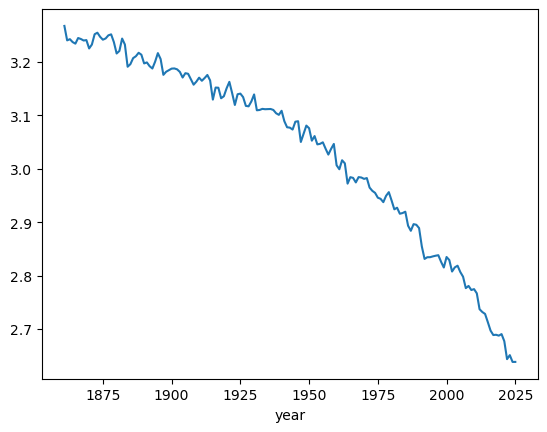

In [10]:
df['OmegaA'].plot()